In [1]:
# importing
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4
from netCDF4 import Dataset
import math
from cartopy.util import add_cyclic_point
from sklearn import linear_model as lm
import statsmodels.formula.api as stm
import statsmodels.api as sm
from sklearn.metrics import r2_score
from numpy import genfromtxt
import rioxarray
from sklearn.linear_model import TheilSenRegressor
from scipy.ndimage import gaussian_filter1d
import requests
import itertools
from scipy.stats import linregress
import scipy.stats

from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import seaborn as sns
#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from rasterio import features
from affine import Affine
import geopandas as gp

plt.rcParams['hatch.linewidth'] = 1.5
plt.rcParams['hatch.color'] = 'k'
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.size'] = "16"
from matplotlib import rcParams
rcParams["mathtext.default"] = "regular"

import warnings
warnings.filterwarnings(action='ignore')

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl2025/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
#data dirs
grace_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GRACE/'
gini_dir = 'dartfs-hpc/rc/lab/C/CMIG/clesk/projects/plcl/data/hydro-gini/'
cpc_dir =  '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CPC/ppt/'
save_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/'
fig_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/'

In [3]:
from matplotlib import colors
root_dir = '/dartfs-hpc/rc/lab/C/CMIG'

In [4]:
# function to aggregate water year
def wyAgg(this_v_m_e_ds,op):
    this_v_m_e_monthly = this_v_m_e_ds
    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    #print('computing NH water year P, ET, Q.', flush=True)
    nh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 10, this_v_m_e_ds.time.dt.year + 1)
    this_v_m_e_monthly['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 7, this_v_m_e_ds.time.dt.year + 1)
    this_v_m_e_monthly['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = this_v_m_e_monthly.lat>=0.0
    northern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = this_v_m_e_monthly.lat<0.0
    southern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[southern_hemi_latmask])

    # aggregate each hemisphere to its respective water-year level:
    print('computing hemispheres.', flush=True)
    if op == 'sum':
        # northern
        this_v_m_e_nhwy_sum = northern_hemi.groupby('water_year_nh').sum(dim='time')
        # southern
        this_v_m_e_shwy_sum = southern_hemi.groupby('water_year_sh').sum(dim='time')
    elif op == 'mean':
        # northern
        this_v_m_e_nhwy_sum = northern_hemi.groupby('water_year_nh').mean(dim='time')
        # southern
        this_v_m_e_shwy_sum = southern_hemi.groupby('water_year_sh').mean(dim='time')
    else:
        print('not a valid operation')
        
    # merge north and southern hemispheres together into one water-year dataset:
    print('merging hemispheres.', flush=True)

    this_v_m_e_nhwy_sum = this_v_m_e_nhwy_sum.rename({'water_year_nh':'water_year'})
    this_v_m_e_shwy_sum = this_v_m_e_shwy_sum.rename({'water_year_sh':'water_year'})

    this_v_m_e_wateryear_sum = xr.merge([this_v_m_e_nhwy_sum, this_v_m_e_shwy_sum])
    this_v_m_e_wateryear_sum = this_v_m_e_wateryear_sum
    
    return this_v_m_e_wateryear_sum

def flipLon360(ds):
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = ds.lon.values + 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift

def detrend_dim(da, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim='water_year', deg=deg)
    fit = xr.polyval(da.water_year, p.polyfit_coefficients)
    return da - fit

### procedure for past impact
simply, delGp (estimated) * mean sensitivity


### procedure for future impact

1) select median Gp year for each grid cell and assemble into composite year
2) compute annual mean dT field pattern scaling from dGMST = +2K
3) amplify daily P C-C P*(t) = P(t)(1+S)^dT
4) randomly/lower sort set years to 0 to conserve total P
5) compute delta Gp field
6) dTWS = dGp * (gamma + chi*meanP)





$\hat{\Delta TWS} = (\hat{\gamma}+\hat{\chi}\overline{P})\hat{\Delta G_{P}}$

### past impact

In [ ]:
cpc_ds

In [7]:
# first we need mean P -- average of 3 products
cpc_ds = xr.open_mfdataset(cpc_dir + '*.nc')

gpcp_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCP/v1.3_daily/'
gpcp_ds = xr.open_mfdataset(gpcp_dir+'gpcp_*.nc')

gpcc_ds = xr.open_mfdataset('/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCC/v2022_daily/*.nc')


In [10]:
styr = 1980
endyr = 2022
P_cpc = wyAgg(cpc_ds.precip,'sum')
P_cpc = P_cpc.sel(water_year=np.arange(styr,endyr+1))
Pmean_cpc = P_cpc.mean('water_year')

In [14]:
styr = 1982
endyr = 2020
P_gpcc = wyAgg(gpcc_ds.precip,'sum')
P_gpcc = P_gpcc.sel(water_year=np.arange(styr,endyr+1))
Pmean_gpcc = P_gpcc.mean('water_year')

Pmean_gpcc = flipLon360(Pmean_gpcc)


computing hemispheres.
merging hemispheres.


In [17]:
styr = 1997
endyr = 2022
gpcp_ds = gpcp_ds.rename({'longitude':'lon','latitude':'lat'})
gpcp_ds = gpcp_ds.precip.where(gpcp_ds.precip != -99999.0, 0)

P_gpcp = wyAgg(gpcp_ds,'sum')
P_gpcp = P_gpcp.sel(water_year=np.arange(styr,endyr+1))
Pmean_gpcp = P_gpcp.mean('water_year')


computing hemispheres.
merging hemispheres.


In [40]:
#regrid to common CPC resolution
Pmean_gpcc_rg = Pmean_gpcc.interp_like(Pmean_cpc)
Pmean_gpcp_rg = Pmean_gpcp.interp_like(Pmean_cpc)


In [44]:
# combine into one dataset and take mean across products
Pmean_ds = xr.concat([Pmean_cpc,Pmean_gpcc_rg,Pmean_gpcp_rg],dim='product')
Pmean = Pmean_ds.mean(dim='product')

#save
Pmean.to_netcdf(save_dir+'P_mean_1980-2022_3product.nc')

Gp trend -- multi-product


In [5]:
#open gini datasets
gp_gpcc = xr.open_dataset(save_dir+'GPCC_daily_pr_gini_water_year_1982-2021.nc')
gp_cpc = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/plcl/data/hydro-gini/annual_daily_pr_gini_CPC_1980-2020.nc')
gp_gpcp =  xr.open_dataset(save_dir+'GPCP_daily_pr_gini_water_year_1997-2022.nc')


In [6]:
# can either specify year range or estimate longest term trend within each product

# full period:
styr = 1980
endyr = 2022

#cpc
gp_trend_cpc = gp_cpc.pr_gini.polyfit('year',deg=1).polyfit_coefficients
#styr = gp_cpc.year.min()
#endyr = gp_cpc.year.max()
delgp_cpc = (endyr-styr+1)*gp_trend_cpc.sel(degree=1)
delgp_cpc = flipLon360(delgp_cpc)

#gpcc
gp_trend_gpcc = gp_gpcc.Pgini_wy.polyfit('water_year',deg=1).polyfit_coefficients
#styr = gp_gpcc.water_year.min()
#endyr = gp_gpcc.water_year.max()
delgp_gpcc = (endyr-styr+1)*gp_trend_gpcc.sel(degree=1)

#gpcp
gp_trend_gpcp = gp_gpcp.Pgini_wy.polyfit('water_year',deg=1).polyfit_coefficients
#styr = gp_gpcp.water_year.min()
#endyr = gp_gpcp.water_year.max()
delgp_gpcp = (endyr-styr+1)*gp_trend_gpcp.sel(degree=1)

delgp_gpcp = delgp_gpcp.interp_like(delgp_cpc).compute()

In [7]:
#combine Gp changes into dataset and take mean 
dGp_ds = xr.concat([delgp_cpc,delgp_gpcc,delgp_gpcp],dim='product')
dGp_ds.pr
dGp_mean = dGp_ds.mean(dim='product')



In [16]:
dGp_ds = dGp_ds.to_dataset(name='dGp')
dGp_ds['product'] = ['CPC','GPCC','GPCP']
dGp_ds.to_netcdf(save_dir+'dGp_trends.nc')

#save dGp mean
dGp_mean.to_netcdf(save_dir+'dGp_1980-2022_3product_mean.nc')

Finally, we need the 3-product mean TWS response:

In [83]:
gamma = np.mean([cpc_results.coef_Gp[0],gpcc_results.coef_Gp[0],gpcp_results.coef_Gp[0]])
chi = np.mean([cpc_results.coef_GpP[0],gpcc_results.coef_GpP[0],gpcp_results.coef_GpP[0]])

In [85]:
# estimate conditional dTWS/dGp based on mean P

dTWS_dGp = gamma+chi*Pmean.precip


In [87]:
dTWS_dGp.to_netcdf(save_dir+'dTWS_dGp_3product_mean.nc')


In [82]:
# load SW regression results (and main model results, for comparison)
cpc_results = pd.read_csv(save_dir+'reg_results/CPC_regression_results.csv')
gpcp_results = pd.read_csv(save_dir+'reg_results/GPCP_regression_results.csv')
gpcc_results = pd.read_csv(save_dir+'reg_results/GPCC_regression_results.csv')

now have three terms (dGp, Pmean, coeffs): can estimate TWS impact

In [343]:
Pmean_ds = xr.open_dataset(save_dir+'P_mean_1980-2022_3product.nc')

In [346]:
dTWS_dGp = xr.open_dataset(save_dir+'dTWS_dGp_3product_mean.nc')
dGp_mean = xr.open_dataset(save_dir+'dGp_1980-2022_3product_mean.nc')

In [351]:
cm_to_mm = 10
dTWS = dTWS_dGp.precip*dGp_mean.polyfit_coefficients*cm_to_mm
dTWS

<xarray.DataArray (lat: 360, lon: 720)> Size: 2MB
array([[-0.02749473, -0.69910189, -0.94863141, ..., -1.40112586,
         8.62470095,  8.64692019],
       [ 4.93908218,  4.10556295,  3.95826976, ...,  3.55000518,
         6.6422314 ,  7.08096739],
       [10.09340859,  9.18671763,  9.11437972, ...,  8.68592081,
        10.4233498 , 11.16043567],
       ...,
       [18.58094243, 17.67281347, 16.95863381, ..., 16.13318044,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]])
Coordinates:
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
    degree   int64 8B ...

### plot

In [354]:
def delta_cmap(vmin,vmax):

    j_cmap_arr = genfromtxt(os.path.join(root_dir, 'nsiegert/projects/c4mip/code/CMAP_RBGA.csv'), delimiter=',')
    j_cmap_arr = np.delete(j_cmap_arr, [1,3,5], 1)
    ncol = 13
    bounds_h = np.linspace(vmin, vmax, ncol)
    cols = colors.ListedColormap(j_cmap_arr, name='j_cmap')(np.linspace(0,1,len(bounds_h)+1))
    cmaph = colors.ListedColormap(cols[1:-1])
    cmaph.set_over(cols[-1])
    cmaph.set_under(cols[1])
    normh = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    return cmaph,normh

#greenland mask
from cartopy.mpl.patch import geos_to_path
from shapely.geometry import Point
import cartopy.io.shapereader as shpreader


shpfilename = shpreader.natural_earth(resolution='50m',
                                      category='cultural',
                                      name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()
country = next(countries)


gl_multipoly, = [country.geometry for country in countries
                 if country.attributes['NAME'] == 'Greenland']

gl_geom = sorted(gl_multipoly.geoms, key=lambda geom: geom.area)


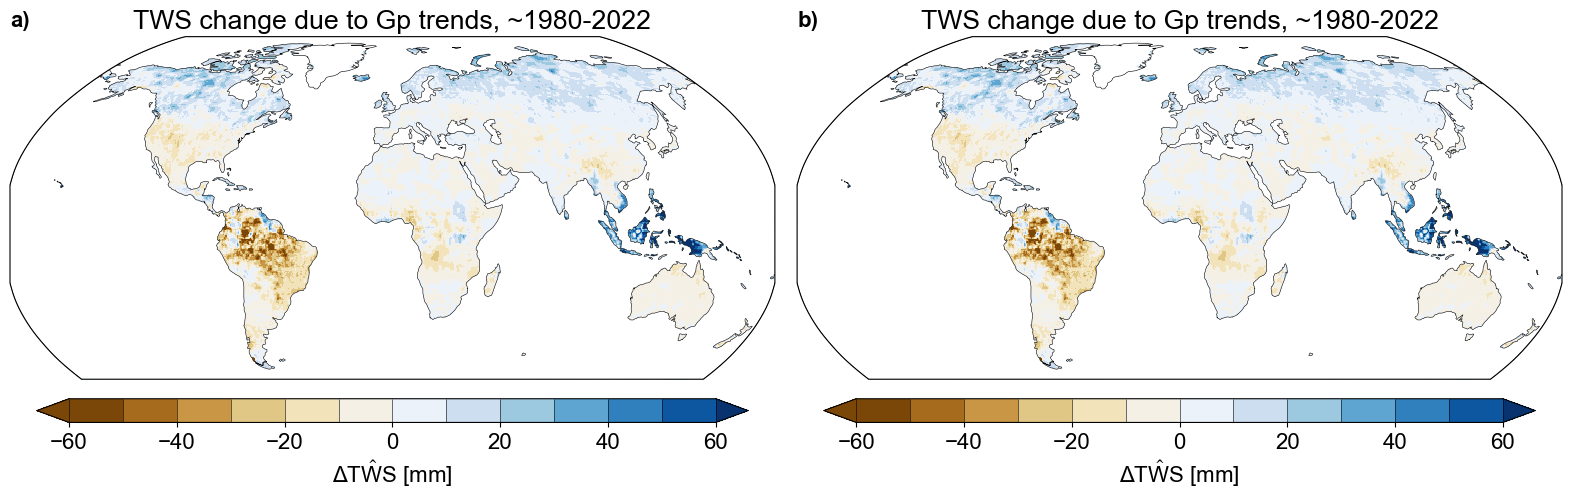

In [355]:
fig = plt.figure(figsize=(16,20))

axs = []
gs = GridSpec(1, 2)

axs.append(fig.add_subplot(gs[0,0],projection=ccrs.Robinson()))
axs.append(fig.add_subplot(gs[0,1],projection=ccrs.Robinson()))

ax = axs[0]

vmin = -60
vmax = 60
cmaph,normh = delta_cmap(vmin,vmax)
lab = r'$\hat{\Delta TWS}$ [mm]'

dTWS.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.93,
                                                      'aspect':30,
                                                      'label':lab,
                                                      'pad':0.01,
                                                      'drawedges':True})

ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.set_title('TWS change due to Gp trends, ~1980-2022')

#######
ax = axs[1]

vmin = -60
vmax = 60
cmaph,normh = delta_cmap(vmin,vmax)
lab = r'$\hat{\Delta TWS}$ [mm]'

dTWS.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.93,
                                                      'aspect':30,
                                                      'label':lab,
                                                      'pad':0.01,
                                                      'drawedges':True})

ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
ax.set_title('TWS change due to Gp trends, ~1980-2022')

# lettering
lets = 'ab'
for i,ax in enumerate(axs):
    ax.text(-0.0,1.03,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    

fig.canvas.draw()
plt.tight_layout(w_pad=1,h_pad=0.1)

In [163]:
weights = np.cos(np.deg2rad(dTWS.lat))
dTWS.weighted(weights).mean(['lat','lon'])

<xarray.DataArray ()> Size: 8B
array(6.85821196)
Coordinates:
    degree   int64 8B 1

Text(0.5, 0, 'Latitude')

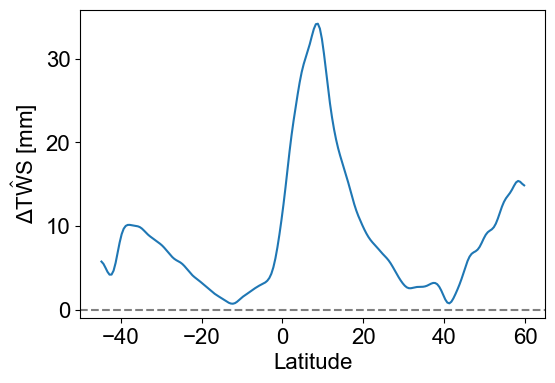

In [182]:
dTWSsub = dTWS.sel(lat=slice(-45,60))
weights = np.cos(np.deg2rad(dTWSsub.lat))
dTWS_zonal = dTWSsub.median('lon')#dTWSsub.weighted(weights).mean('lon')
dTWS_zonal = gaussian_filter1d(dTWS_zonal,sigma=2)

fig,ax = plt.subplots(figsize=(6,4))
ax.plot(dTWSsub.lat,dTWS_zonal)
ax.axhline(0,linestyle='--',color='grey')

ax.set_ylabel('$\hat{\Delta TWS}$ [mm]')
ax.set_xlabel('Latitude')

### projection
1) build composite median Gp precip year ds


In [5]:
gpcc_ds = xr.open_mfdataset('/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCC/v2022_daily/*.nc')
gpcc_ds = flipLon360(gpcc_ds)
gp_gpcc = gp_gpcc.interp_like(gpcc_ds)

NameError: name 'gp_gpcc' is not defined

In [58]:
start_year = 2002
median_gini = gp_gpcp.sel(water_year=slice(start_year,2022)).median(dim='water_year',skipna=True)

# Find the absolute difference between pr_gini and median_gini, ignoring NaNs
abs_diff = abs(gp_gpcp.sel(water_year=slice(start_year,2022)) - median_gini)

# Mask out NaN values to avoid all-NaN slices
valid_mask = ~np.isnan(abs_diff)
abs_diff = abs_diff.where(valid_mask, 0)
closest_year_idx = abs_diff.argmin(dim='water_year')
selected_years = gp_gpcp.sel(water_year=slice(start_year,2022)).water_year[closest_year_idx.Pgini_wy]

# create mask to select given median Gp year
years = gpcp_ds['time.year']  
mask = years == selected_years

# extract the corresponding daily data
selected_pr = gpcp_ds.where(mask, drop=True)

# reshape new composite daily P
selected_pr = selected_pr.groupby('time.dayofyear').mean('time')

# rename time less clunky
selected_pr = selected_pr.rename({'dayofyear': 'day'})

#mask ocean
mask = xr.open_dataset(save_dir+'IMERG_land_sea_mask.nc')
mask = mask.interp_like(gpcp_ds.sel(time=gpcp_ds.time[0]))
mask = mask.landseamask < 75
gpcp_mask = selected_pr.where(mask)

gpcc_mask.to_netcdf(save_dir + 'GPCP_mean_Gp_year_daily_precip_composite.nc')


In [431]:
### gpcc

start_year = 2002
median_gini = gp_gpcc.sel(water_year=slice(start_year,2021)).median(dim='water_year',skipna=True)

# Find the absolute difference between pr_gini and median_gini, ignoring NaNs
abs_diff = abs(gp_gpcc.sel(water_year=slice(start_year,2021)) - median_gini)


# Mask out NaN values to avoid all-NaN slices
valid_mask = ~np.isnan(abs_diff)
abs_diff = abs_diff.where(valid_mask, 0)
closest_year_idx = abs_diff.argmin(dim='water_year')
selected_years = gp_gpcc.sel(water_year=slice(start_year,2021)).water_year[closest_year_idx.Pgini_wy]

# create mask to select given median Gp year
years = gpcc_ds['time.year']  
mask = years == selected_years

# extract the corresponding daily data
selected_pr = gpcc_ds.where(mask, drop=True)


In [433]:

# reshape new composite daily P
selected_pr = selected_pr.groupby('time.dayofyear').mean('time')

# rename time less clunky
selected_pr = selected_pr.rename({'dayofyear': 'day'})

#mask ocean
mask = xr.open_dataset(save_dir+'IMERG_land_sea_mask.nc')
mask = mask.interp_like(gpcc_ds.sel(time=gpcc_ds.time[0]))
mask = mask.landseamask < 75
gpcc_mask = selected_pr.where(mask)

In [436]:
gpcc_mask.to_netcdf(save_dir + 'GPCC_mean_Gp_year_daily_precip_composite.nc')


2) Then we need a scaling factor to intensify this composite year precip by
 - This is $ f = (1+s)^{\Delta \overline{T}}$
 - s is easy -- we just set a scaling rate, here Clausius-Clapeyron (7%/K) to start
 - $\Delta \overline{T} $ is lon x lat and is the annual mean local temperature change at a given $\Delta$GMSAT level
 - we obtain this from the average of some CMIP6 models

In [5]:
T_thresh = 1

def gini(x):
    # computes unweighted gini index on a vector
    # from: https://stackoverflow.com/questions/39512260/calculating-gini-coefficient-in-python-numpy
    # equivalent to (np.sum((2 * index - n  - 1) * x)) / (n * np.sum(x)), which is more common notation but slower
    
    n = len(x)
    
    # if obs missing, drop
    x[np.isnan(x)] = np.median(x)
    
    cumx = np.cumsum(x, dtype=float)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

In [9]:
# set up ensemble
tas_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/ClimateModels/CMIP6/ssp245/tas_Amon/'
hist_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/ClimateModels/CMIP6/historical/tas_Amon/'

def unique(lst):
 
    unique_list = []
    for x in lst:
        if x not in unique_list:
            unique_list.append(x)
    return unique_list

fnames = os.listdir(tas_dir)
for fn in fnames:
    if (fn[0] == '.') or (fn[0] == 'w'):
        fnames.remove(fn)

models = unique([fn.split('_')[2] for fn in fnames])[:-4]

skipmods = ['IITM-ESM','MCM-UA-1-0','KIOST-ESM','NESM3','CAS-ESM2-0','FIO-ESM-2-0','CIESM']
for sm in skipmods:
    models.remove(sm)
    
#populate variants per model
modvars = {}
for model in models:
    
    fnames = glob.glob(tas_dir+'tas_Amon_'+model+'*.nc')
    modvars[model] = unique([fn.split('/')[-1].split('_')[4] for fn in fnames])
    

In [11]:
fnames = os.listdir(hist_dir)
for fn in fnames:
    if (fn[0] == '.') or (fn[0] == 'w'):
        fnames.remove(fn)

modelshist = unique([fn.split('_')[2] for fn in fnames])[:-4]

In [17]:
models

['MPI-ESM1-2-HR',
 'EC-Earth3',
 'GISS-E2-1-G',
 'CanESM5',
 'MRI-ESM2-0',
 'GISS-E2-1-H',
 'MIROC6',
 'MPI-ESM1-2-LR',
 'CNRM-CM6-1',
 'UKESM1-0-LL',
 'ACCESS-ESM1-5',
 'CESM2-WACCM',
 'CMCC-ESM2',
 'AWI-CM-1-1-MR',
 'FGOALS-g3',
 'CAMS-CSM1-0',
 'NorESM2-LM',
 'KACE-1-0-G',
 'CNRM-ESM2-1',
 'CESM2',
 'NorESM2-MM',
 'MIROC-ES2L',
 'IPSL-CM6A-LR',
 'ACCESS-CM2',
 'HadGEM3-GC31-LL',
 'FGOALS-f3-L',
 'INM-CM4-8',
 'GFDL-ESM4',
 'INM-CM5-0',
 'BCC-CSM2-MR',
 'CMCC-CM2-SR5']

In [18]:
# now loop through models and compute local dT at +1deg GMSAT
dTlist = []

for model in models:
    print(model)
    variant = modvars[model][0]

    # skip models that don't have hist runs availabile
    try:
        hist = xr.open_mfdataset(hist_dir+'tas_Amon_'+model+'_historical_'+variant+'*.nc')

    except:
        print('no hist')
        continue

    #open temp
    ds = xr.open_mfdataset(tas_dir+'tas_Amon_'+model+'_ssp245_'+variant+'*.nc')

    #subtract historical 1995-2014 mean from ssp2-4.5 to get warming since study period:
    histmean = hist.groupby('time.year').mean('time').sel(year=slice(1995,2015)).mean('year')
    ds = ds - histmean

    #global mean
    weights = np.cos(np.deg2rad(ds.lat))
    gmsat = ds.tas.weighted(weights).mean(['lon','lat'])
    gmsat = gmsat.groupby('time.year').mean().rolling(year=30).mean()
    #get year of +1deg
    toe = gmsat.year[np.where(gmsat>1)[0].min()].compute()
    
    # local warming pattern
    dT = ds.sel(time = slice(str(toe.data-29)+'-01-01',str(toe.data+1)+'-01-01')).tas.mean('time')
    dT = dT.interp_like(cpc_ds.sel(time=cpc_ds.time[0]))
    
    #store
    dTlist.append(dT)
    

MPI-ESM1-2-HR
EC-Earth3
GISS-E2-1-G
CanESM5
MRI-ESM2-0
no hist
GISS-E2-1-H
MIROC6
MPI-ESM1-2-LR
CNRM-CM6-1
no hist
UKESM1-0-LL
ACCESS-ESM1-5
CESM2-WACCM
CMCC-ESM2
AWI-CM-1-1-MR
FGOALS-g3
CAMS-CSM1-0
NorESM2-LM
KACE-1-0-G
CNRM-ESM2-1
no hist
CESM2


In [193]:
# setup xr ds and save
dTds = xr.concat(dTlist,dim='model',coords='minimal',compat='override')

In [196]:
dTds.to_netcdf(save_dir+'CMIP6_ensemble_mean_tas_change_GMSAT1decC.nc')

3. Next, we scale the precip, adjust to constant P
- $P'(t) = fP(t)$
- add dry days to keep total P constant
- then compute the $\Delta G_P$ field


In [440]:
gpcp = xr.open_dataset(save_dir+'GPCC_mean_Gp_year_daily_precip_composite.nc')
gpcp = gpcp.precip

In [441]:
dTds = xr.open_dataset(save_dir+'CMIP6_ensemble_mean_tas_change_GMSAT1decC.nc')
dTds = dTds.interp_like(gpcp)
dTds = dTds.mean('model')

In [442]:
# scale daily P by scaling and dT field
s = 0.07
f = (1+s)**dTds.tas
gpcp_int = (gpcp*f).compute()

# compute the added precip by doing this (we will adjust for this)
dP = (gpcp_int.sum('day') - gpcp.sum('day')).compute()

# save this as takes a while to compute
gpcp_int.to_netcdf(save_dir+'projections_P_GPCC_int_7pct_K.nc')
dP.to_netcdf(save_dir+'projections_dP_GPCC_int_7pct_K.nc')

In [445]:
# load dP and intensified P
gpcp_int = xr.open_dataset(save_dir+'projections_P_GPCC_int_7pct_K.nc')
dP = xr.open_dataset(save_dir+'projections_dP_GPCC_int_7pct_K.nc')

gpcp_int = gpcp_int.__xarray_dataarray_variable__
dP = dP.__xarray_dataarray_variable__
dP = np.abs(dP)

# get rid of leap day
gpcp_int = gpcp_int.isel(day=slice(0, 365))
gpcp = gpcp.isel(day=slice(0, 365))

In [446]:
# add dry days to keep total P constant
pintsort = np.sort(gpcp_int, axis=0)
cumsum_pintsort = np.cumsum(pintsort, axis=0)
cumsum_pintsort = xr.DataArray(cumsum_pintsort,coords={'day':gpcp_int.day,'lat':gpcp_int.lat,'lon':gpcp_int.lon})
pintsort = xr.DataArray(pintsort,coords={'day':gpcp_int.day,'lat':gpcp_int.lat,'lon':gpcp_int.lon})

N = (cumsum_pintsort < dP).sum(dim="day") 
rank = pintsort.argsort(axis=0) 

# Create mask: True for values to be zeroed
mask = rank < N  # (lon, lat, time)

# Apply mask to set values to 0
gpcp_int_dd = pintsort.copy()  # Make a copy to modify
gpcp_int_dd.values[mask] = 0 

In [617]:
# keep track of additional dry days
dDD = (gpcp_int_dd<1).sum('day') - (gpcp_int<1).sum('day')


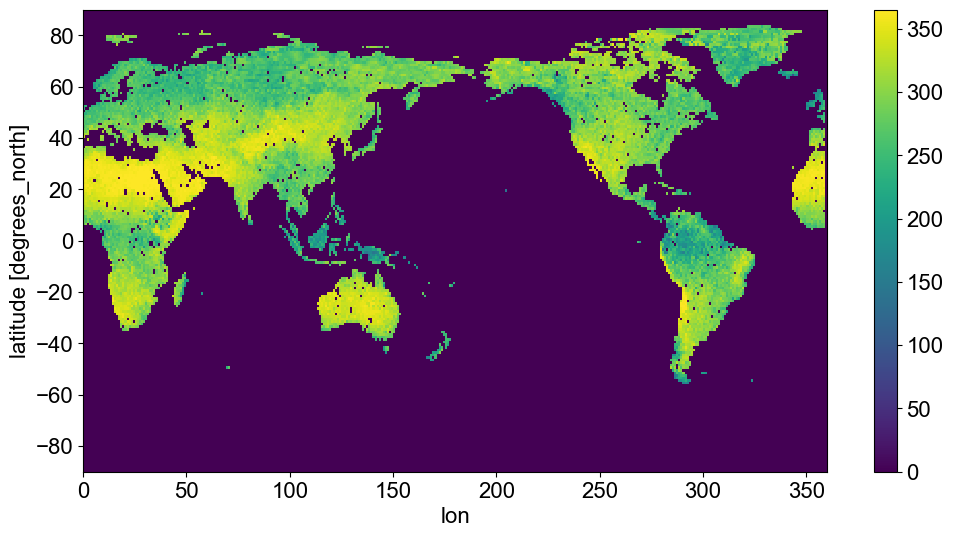

In [616]:
(gpcp_int_dd==0).sum('day').plot()

In [447]:
#dGp field

#calculate original Gp 
gp = np.apply_along_axis(gini,0,pintsort.values)

#calculate intensified and dry-day adjusted Gp 
gp_int = np.apply_along_axis(gini,0,gpcp_int_dd.values)

# finally, difference:
dgp = gp_int-gp
dgp_ds = xr.DataArray(dgp,coords={'lat':gpcp_int.lat,'lon':gpcp_int.lon})

# save
dgp_ds.to_netcdf(save_dir+'projections_dGp_GPCC_int_7pct_K.nc')

4. Finally, dTWS = dGp*(gamma + chi*Pmean)
- And plot

In [7]:
# load all data (start here if above already computed)
dgp_ds = xr.open_dataset(save_dir+'projections_dGp_GPCC_int_7pct_K.nc')
Pmean_ds = xr.open_dataset(save_dir+'P_mean_1980-2022_3product.nc')
dTWS_dGp = xr.open_dataset(save_dir+'dTWS_dGp_3product_mean.nc')
dTWS_dGp = dTWS_dGp.interp_like(dgp_ds)
cm_to_mm = 10
dTWS_future = dTWS_dGp.precip*dgp_ds*cm_to_mm


In [8]:
### get TWS SD from GRACE to normalize changes (for inset)
grace_ds = xr.open_dataset(save_dir+'GRACE_LWE_wateryear.nc')

#trim GRACE to study period, interp grid, 
grace_ds = grace_ds.sel(water_year=np.arange(2002,2023))
grace = grace_ds.interp_like(dTWS_future)

#setup landmask for GRACE
mask = xr.open_dataset(save_dir+'IMERG_land_sea_mask.nc')
mask = mask.interp_like(grace)
mask = mask.landseamask < 75

# remove incomplete mission water-years and land mask
grace = grace.sel(water_year=~grace.water_year.isin([2002,2017,2022])).where(mask)

# SD TWS
grace_detrend = detrend_dim(grace.lwe_thickness)
grace_sd = grace_detrend.std('water_year')
grace_sd = grace_sd*cm_to_mm

In [9]:
Pmean_ds = xr.open_dataset(save_dir+'P_mean_1980-2022_3product.nc')

In [10]:
dTWS_dGp = xr.open_dataset(save_dir+'dTWS_dGp_3product_mean.nc')
dGp_mean = xr.open_dataset(save_dir+'dGp_1980-2022_3product_mean.nc')

In [11]:
cm_to_mm = 10
dTWS = dTWS_dGp.precip*dGp_mean.polyfit_coefficients*cm_to_mm
dTWS

<xarray.DataArray (lat: 360, lon: 720)> Size: 2MB
array([[-0.02749473, -0.69910189, -0.94863141, ..., -1.40112586,
         8.62470095,  8.64692019],
       [ 4.93908218,  4.10556295,  3.95826976, ...,  3.55000518,
         6.6422314 ,  7.08096739],
       [10.09340859,  9.18671763,  9.11437972, ...,  8.68592081,
        10.4233498 , 11.16043567],
       ...,
       [18.58094243, 17.67281347, 16.95863381, ..., 16.13318044,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]])
Coordinates:
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
    degree   int64 8B ...

In [12]:
dTWS_future_norm = dTWS_future/grace_sd
dTWS_future_norm = dTWS_future_norm.__xarray_dataarray_variable__
dTWS_norm = dTWS.interp_like(grace_sd)/grace_sd

In [13]:
pop = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/ISIMIP_pop/population_rcp26soc_0p5deg_annual_2006-2099.nc4',decode_times=False)

pop=pop.sel(time=165).number_of_people
pop = flipLon360(pop)
pop = pop.interp_like(dTWS_norm)

TWS_values = dTWS_norm.values.flatten()
pop_weights = pop.values.flatten()

# Remove NaNs if necessary
valid = ~np.isnan(TWS_values) & ~np.isnan(pop_weights)
TWS_values, pop_weights = TWS_values[valid], pop_weights[valid]

# Create weighted histogram
bins = np.arange(-2,2.1,0.2)  # Define bin edges
hist, bin_edges_past = np.histogram(TWS_values, bins=bins, weights=pop_weights)  # Weighted count

# Normalize by total population to get "fraction of population"
hist_past = hist / hist.sum() *100

TWS_values = dTWS_future_norm.values.flatten()
pop_weights = pop.values.flatten()

# Remove NaNs if necessary
valid = ~np.isnan(TWS_values) & ~np.isnan(pop_weights)
TWS_values, pop_weights = TWS_values[valid], pop_weights[valid]

# Create weighted histogram
bins = np.arange(-2,0.1,0.1)  # Define bin edges
hist, bin_edges_future = np.histogram(TWS_values, bins=bins, weights=pop_weights)  # Weighted count

# Normalize by total population to get "fraction of population"
hist_future = hist / hist.sum() *100

In [14]:
## annual population weighted mean P
popfrac = pop/pop.sum(['lon','lat'])
(popfrac*cpc_annual).sum(['lon','lat'])

NameError: name 'cpc_annual' is not defined

In [15]:
#wrap lon
def cycregrid(da):

    datrep = da.sel(lon=da.lon[-4]).values
    dat = da.values
    dat[:,0] = datrep+0.000001
    dat[:,-1] = datrep+0.000001
    #dat[:,-2] = datrep+0.000002
    #dat[:,-3] = datrep+0.000002

    cycdat = xr.DataArray(data=dat,
                              dims=['lat','lon'],
                              coords=(da.lat.data,da.lon.data))

    return cycdat


dTWS_wrap = cycregrid(dTWS_future.__xarray_dataarray_variable__)


In [16]:
#colormaps
def delta_cmap(vmin,vmax):

    j_cmap_arr = genfromtxt(os.path.join(root_dir, 'nsiegert/projects/c4mip/code/CMAP_RBGA.csv'), delimiter=',')
    j_cmap_arr = np.delete(j_cmap_arr, [1,3,5], 1)
    ncol = 13
    bounds_h = np.linspace(vmin, vmax, ncol)
    cols = colors.ListedColormap(j_cmap_arr, name='j_cmap')(np.linspace(0,1,len(bounds_h)+1))
    cmaph = colors.ListedColormap(cols[1:-1])
    cmaph.set_over(cols[-1])
    cmaph.set_under(cols[1])
    normh = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    return cmaph,normh

def b_cmap(vmin,vmax):

    j_cmap_arr = genfromtxt(os.path.join(root_dir, 'nsiegert/projects/c4mip/code/CMAP_RBGA.csv'), delimiter=',')
    j_cmap_arr = np.delete(j_cmap_arr, [1,3,5], 1)
    j_cmap_arr = j_cmap_arr[:68,:]
    ncol = 13
    bounds_h = np.linspace(vmin, vmax, ncol)
    cols = colors.ListedColormap(j_cmap_arr, name='j_cmap')(np.linspace(0,1,len(bounds_h)+1))
    cmaph = colors.ListedColormap(cols[1:-1])
    cmaph.set_over(cols[-1])
    cmaph.set_under(cols[1])
    normh = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    return cmaph,normh

#greenland mask
from cartopy.mpl.patch import geos_to_path
from shapely.geometry import Point
import cartopy.io.shapereader as shpreader


shpfilename = shpreader.natural_earth(resolution='50m',
                                      category='cultural',
                                      name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()
country = next(countries)


gl_multipoly, = [country.geometry for country in countries
                 if country.attributes['NAME'] == 'Greenland']

gl_geom = sorted(gl_multipoly.geoms, key=lambda geom: geom.area)


In [17]:
j_cmap_arr = genfromtxt(os.path.join(root_dir, 'nsiegert/projects/c4mip/code/CMAP_RBGA.csv'), delimiter=',')
j_cmap_arr = np.delete(j_cmap_arr, [1,3,5], 1)
lightb = j_cmap_arr[50,:]

### now plot historical attribution and projections, with population-weighted inset histograms

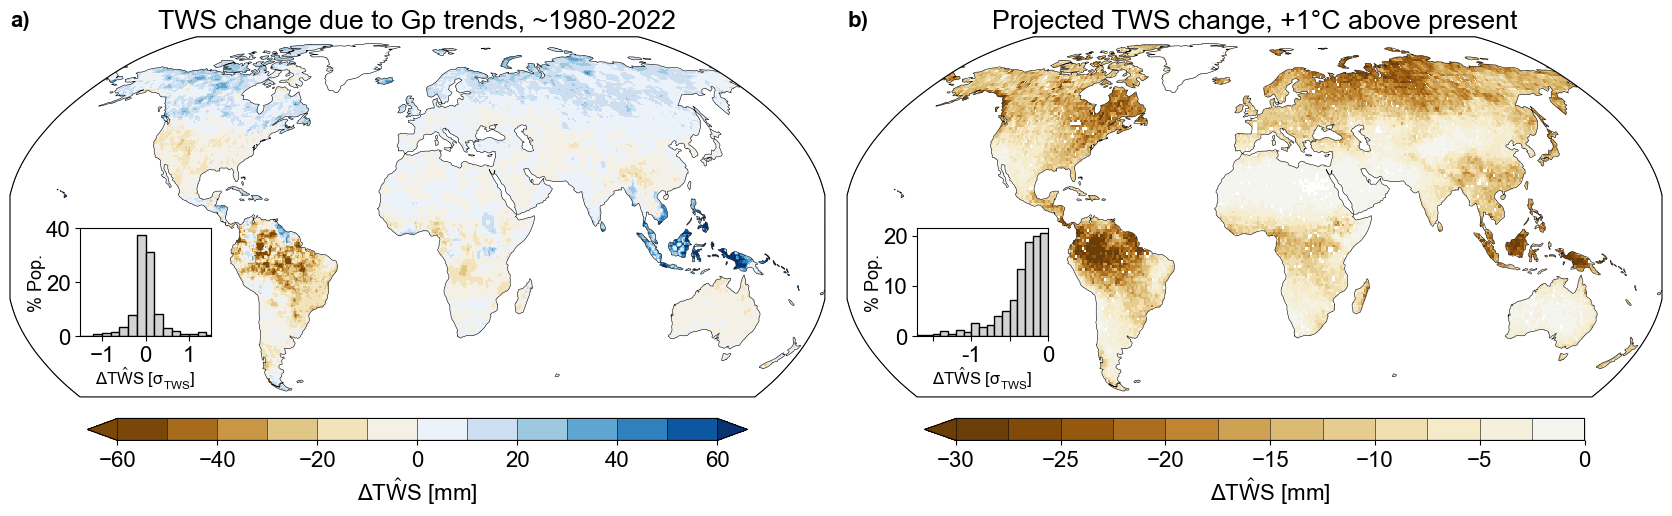

In [ ]:
fig = plt.figure(figsize=(17,22))

axs = []
gs = GridSpec(1, 2)

axs.append(fig.add_subplot(gs[0,0],projection=ccrs.Robinson()))
axs.append(fig.add_subplot(gs[0,1],projection=ccrs.Robinson()))

ax = axs[0]

vmin = -60
vmax = 60
cmaph,normh = delta_cmap(vmin,vmax)
lab = r'$\hat{\Delta TWS}$ [mm]'

dTWS.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.81,
                                                      'aspect':30,
                                                      'label':lab,
                                                      'pad':0.01,
                                                      'drawedges':True})

ax.set_extent((-180,180,-58,90), crs=ccrs.PlateCarree())
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.set_title('TWS change due to Gp trends, ~1980-2022')

ax_inset = inset_axes(ax, width="100%", height="100%", 
                      bbox_to_anchor=(0.1, 0.2, 0.16, 0.3),  # (x, y, width, height) in figure fraction
                      bbox_transform=ax.transAxes)
bins = np.arange(-11,11,2)
#ax_inset.hist(dTWS_norm.values.flatten(),bins,density=True,color="lightgray",
#              linewidth=1,edgecolor="black",
#             alpha=1)

ax_inset.bar(bin_edges_past[:-1], hist_past, width=np.diff(bin_edges_past), align="edge",color="lightgray",
             linewidth=1,edgecolor="black",
            alpha=1)
ax_inset.set_xlabel(r'$ \hat{\Delta TWS}$' +' $[\sigma_{TWS}]$',fontsize=12,labelpad=0.1)
ax_inset.set_ylabel('% Pop.',fontsize=13,labelpad=0.1)
ax_inset.set_yticks([0,20,40])
ax_inset.set_xlim([-1.5,1.5])

#######
ax = axs[1]

vmin = -30
vmax = 0
bounds = np.arange(vmin, 5, 5)  # [-30, -25, -20, -15, -10, -5, 0]
cmap,norm = b_cmap(vmin,vmax)
lab = r'$\hat{\Delta TWS}$ [mm]'

dTWS_wrap.plot.pcolormesh(transform=ccrs.PlateCarree(),ax=ax,cmap=cmap,norm=norm,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.81,
                                                      'aspect':30,
                                                      'label':lab,
                                                      'pad':0.01,
                                                      'drawedges':True})

ax.set_extent((-180,180,-58,90), crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
ax.set_title('Projected TWS change, +1°C above present')

ax_inset = inset_axes(ax, width="100%", height="100%", 
                      bbox_to_anchor=(0.1, 0.2, 0.16, 0.3),  # (x, y, width, height) in figure fraction
                      bbox_transform=ax.transAxes)
bins = np.arange(-2,.1,.1)
# ax_inset.hist(dTWS_future_norm.values.flatten(),bins,density=True,color='lightgrey',
#               linewidth=1,edgecolor="black",
#              alpha=1)

ax_inset.bar(bin_edges_future[:-1], hist_future, width=np.diff(bin_edges_future), align="edge",color="lightgray",
             linewidth=1,edgecolor="black",
            alpha=1)

ax_inset.set_xlabel(r'$ \hat{\Delta TWS}$' +' $[\sigma_{TWS}]$',fontsize=12,labelpad=0.1)
ax_inset.set_ylabel('% Pop.',fontsize=13,labelpad=0.1)
ax_inset.set_yticks([0,10,20])
ax_inset.set_xticks([-1.5,-1,-0.5,0])
ax_inset.set_xticklabels(['','-1','','0'])

ax_inset.set_xlim([-1.7,0])

# lettering
lets = 'ab'
for i,ax in enumerate(axs):
    ax.text(-0.0,1.03,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    

fig.canvas.draw()
plt.tight_layout(w_pad=1,h_pad=0.1)

#plt.savefig('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/clean/Fig.5.pdf',bbox_inches='tight')

### plot terms in dTWS estimate:
- for SI
- dT
- dGp
- dTWS_dGp
- eventually dDD would be cool

In [18]:
dT = cycregrid(dTds.tas)
dGp = cycregrid(dgp_ds) 
dtwsdgp = cycregrid(dTWS_dGp.precip)
dDD = cycregrid(dDD)

ValueError: could not broadcast input array from shape (26,360) into shape (26,720)

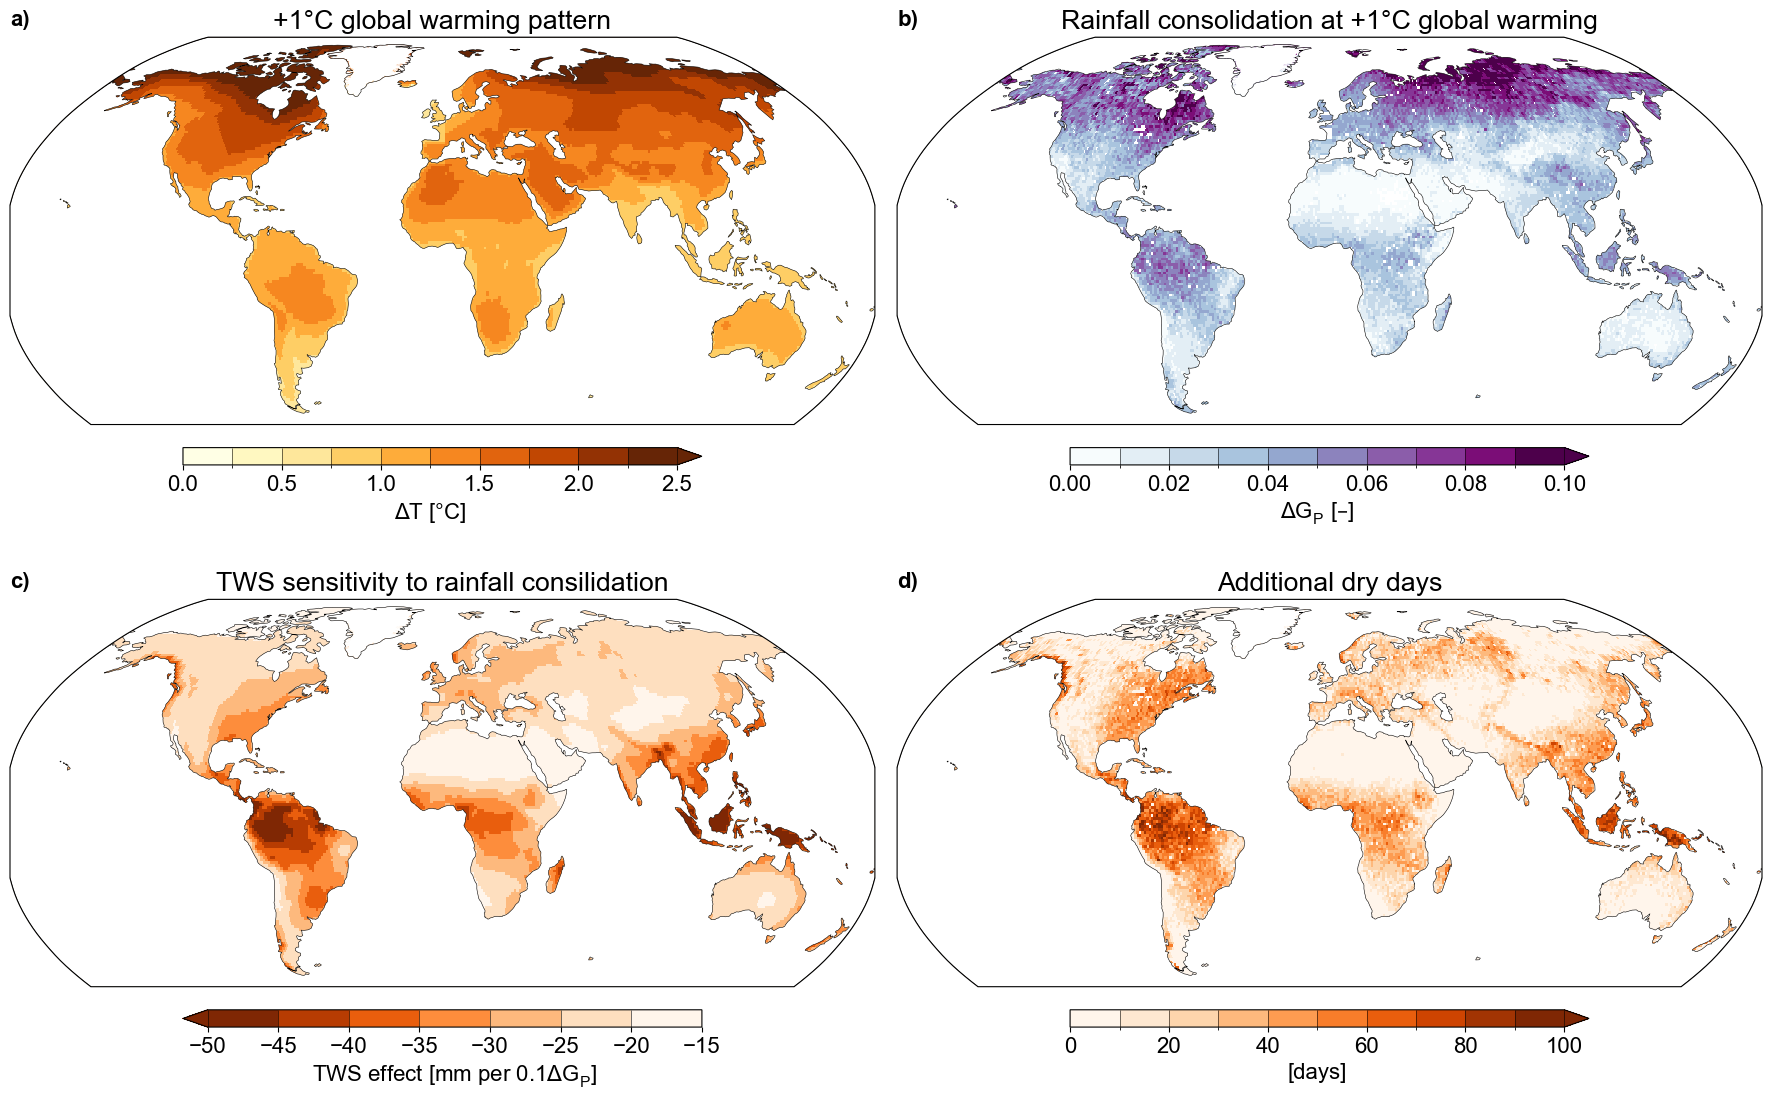

In [621]:
fig = plt.figure(figsize=(18,12))

axs = []
gs = GridSpec(1,3)

axs.append(fig.add_subplot(gs[0,0],projection=ccrs.Robinson()))
axs.append(fig.add_subplot(gs[0,1],projection=ccrs.Robinson()))
axs.append(fig.add_subplot(gs[0,2],projection=ccrs.Robinson()))

shrink = 0.6

ax = axs[0]

vmin = 0
vmax = 2.5
bounds = np.arange(vmin,vmax+.1, 0.25)  
cmap = plt.get_cmap("YlOrBr", len(bounds) - 1)  # Must match len(bounds) - 1
norm = matplotlib.colors.BoundaryNorm(boundaries=bounds, ncolors=len(bounds) - 1, clip=False)
lab = r'$\Delta T$ [°C]'

dT.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmap,norm=norm,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':shrink,
                                                      'aspect':30,
                                                      'label':lab,
                                                      'pad':0.04,
                                                      'drawedges':True})

ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.set_title('+1°C global warming pattern')

# #######
ax = axs[1]

vmin = 0
vmax = 0.1
bounds = np.arange(vmin,vmax+.01, 0.01)  
cmap = plt.get_cmap("BuPu", len(bounds) - 1)  # Must match len(bounds) - 1
norm = matplotlib.colors.BoundaryNorm(boundaries=bounds, ncolors=len(bounds) - 1, clip=False)
lab = r'$\Delta G_P$ [–]'

dgp_ds.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmap,norm=norm,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':shrink,
                                                      'aspect':30,
                                                      'label':lab,
                                                      'pad':0.04,
                                                      'drawedges':True})

ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.set_title('Rainfall consolidation at +1°C global warming')


ax = axs[2]

vmin = -50
vmax = -15
bounds = np.arange(vmin,vmax+.1, 5)  # [-30, -25, -20, -15, -10, -5, 0]
cmap = plt.get_cmap("Oranges_r", len(bounds) - 1)  # Must match len(bounds) - 1
norm = matplotlib.colors.BoundaryNorm(boundaries=bounds, ncolors=len(bounds) - 1, clip=False)
lab = r'TWS effect [mm per 0.1$\Delta G_P$]'

dtwsdgp.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmap,norm=norm,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':shrink,
                                                      'aspect':30,
                                                      'label':lab,
                                                      'pad':0.04,
                                                      'drawedges':True})

ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.set_title('TWS sensitivity to rainfall consilidation')

ax = axs[3]

vmin = 0
vmax = 100
bounds = np.arange(vmin,vmax+.1, 10)  # [-30, -25, -20, -15, -10, -5, 0]
cmap = plt.get_cmap("Oranges", len(bounds) - 1)  # Must match len(bounds) - 1
norm = matplotlib.colors.BoundaryNorm(boundaries=bounds, ncolors=len(bounds) - 1, clip=False)
lab = r'[days]'

dDD.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmap,norm=norm,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':shrink,
                                                      'aspect':30,
                                                      'label':lab,
                                                      'pad':0.04,
                                                      'drawedges':True})

ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.set_title('Additional dry days')

# lettering
lets = 'abcd'
for i,ax in enumerate(axs):
    ax.text(-0.0,1.03,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    

fig.canvas.draw()
plt.tight_layout(w_pad=1,h_pad=0.1)